In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,classification_report

In [14]:
pip install seaborn --upgrade

^C
Note: you may need to restart the kernel to use updated packages.


In [4]:
#Load the dataset
#df = pd.read_csv("../data/diabetes_012_health_indicators_BRFSS2015.csv")
#df = pd.read_csv("../data/diabetes_binary_5050split_health_indicators_BRFSS2015.csv")
df = pd.read_csv("../data/diabetes_binary_health_indicators_BRFSS2015.csv")
#Display the first few rows
print(df.head())

   Diabetes_binary  HighBP  HighChol  CholCheck   BMI  Smoker  Stroke  \
0              0.0     1.0       1.0        1.0  40.0     1.0     0.0   
1              0.0     0.0       0.0        0.0  25.0     1.0     0.0   
2              0.0     1.0       1.0        1.0  28.0     0.0     0.0   
3              0.0     1.0       0.0        1.0  27.0     0.0     0.0   
4              0.0     1.0       1.0        1.0  24.0     0.0     0.0   

   HeartDiseaseorAttack  PhysActivity  Fruits  ...  AnyHealthcare  \
0                   0.0           0.0     0.0  ...            1.0   
1                   0.0           1.0     0.0  ...            0.0   
2                   0.0           0.0     1.0  ...            1.0   
3                   0.0           1.0     1.0  ...            1.0   
4                   0.0           1.0     1.0  ...            1.0   

   NoDocbcCost  GenHlth  MentHlth  PhysHlth  DiffWalk  Sex   Age  Education  \
0          0.0      5.0      18.0      15.0       1.0  0.0   9.0   

In [6]:
#Gather the date
X = df.drop("Diabetes_binary", axis=1)
y = df["Diabetes_binary"]

# X = df.drop("Diabetes_012", axis=1)
# y = df["Diabetes_012"]

In [7]:
X_train, X_test, y_train, y_test= train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [8]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [14]:
from sklearn.ensemble import GradientBoostingClassifier

gbc = GradientBoostingClassifier(n_estimators=300,
                                 learning_rate=0.05,
                                 random_state=100,
                                 max_features=5 )
gbc.fit(X_train, y_train)

pred_y = gbc.predict(X_test)

acc = accuracy_score(y_test, pred_y)
print("Gradient Boosting Classifier accuracy is : {:.2f}".format(acc))
print(classification_report(y_test, pred_y))

0.8648494165878272
              precision    recall  f1-score   support

         0.0       0.88      0.98      0.93     43667
         1.0       0.55      0.17      0.26      7069

    accuracy                           0.86     50736
   macro avg       0.71      0.57      0.59     50736
weighted avg       0.83      0.86      0.83     50736



In [18]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

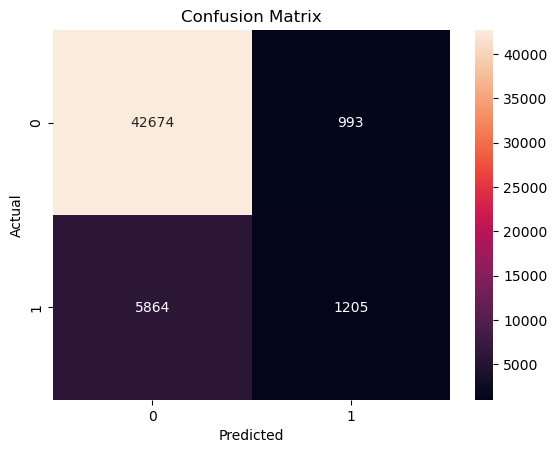

In [19]:
cm = confusion_matrix(y_test, pred_y)

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:
#########

In [16]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr_model.coef_[0]
})

importance.sort_values(
    by="Coefficient",
    ascending=False,
    inplace=True
)

print(importance)

AttributeError: 'GradientBoostingClassifier' object has no attribute 'coef_'

In [ ]:
########################

Risk Analysis

In [22]:
risk_scores = gbc.predict_proba(X_test)[:,1]
risk_scores

array([0.16221488, 0.38022206, 0.01613169, ..., 0.00464761, 0.15907088,
       0.0117153 ])

In [ ]:
###PAUSE###########

In [23]:
results = X_test.copy()
results["Outcome"] = y_test.copy()
results["RiskScore"] = risk_scores

results["RiskGroup"] = pd.cut(
    results["RiskScore"],
    bins=[0,0.3,0.7,1],
    include_lowest=True,
    labels=["Low", "Medium", "High"]
)

In [24]:
results["RiskGroup"]

128677       Low
225051    Medium
27174        Low
132371       Low
164896    Medium
           ...  
48574        Low
230352       Low
134904       Low
1376         Low
69400        Low
Name: RiskGroup, Length: 50736, dtype: category
Categories (3, object): ['Low' < 'Medium' < 'High']

In [25]:
results["RiskGroup"].value_counts()
#Low = (41826) 82.4%
#Medium = (8560) 16.9%
#High= (350) 0.7%

RiskGroup
Low       42915
Medium     7686
High        135
Name: count, dtype: int64

In [26]:
high_risk = results[
    results["RiskGroup"] == "High"
]

In [27]:
high_risk.mean(numeric_only=True)
#Age 9 = 60 to 64 | Age 10 = 65 to 79 
#Edu 4 = College 1 year to 3 years| Edu 5 = College 4 years or more
#Income 5 = $25,000 to less than $35,000| 6 = $35,000 to less than $50,000

HighBP                   1.000000
HighChol                 1.000000
CholCheck                1.000000
BMI                     44.859259
Smoker                   0.488889
Stroke                   0.414815
HeartDiseaseorAttack     0.696296
PhysActivity             0.370370
Fruits                   0.533333
Veggies                  0.688889
HvyAlcoholConsump        0.000000
AnyHealthcare            0.948148
NoDocbcCost              0.177778
GenHlth                  4.748148
MentHlth                 8.792593
PhysHlth                17.548148
DiffWalk                 0.925926
Sex                      0.518519
Age                      9.229630
Education                4.318519
Income                   3.785185
Outcome                  0.755556
RiskScore                0.734786
dtype: float64

In [28]:
low_risk = results[
    results["RiskGroup"] == "Low"
]

In [29]:
low_risk.mean(numeric_only=True)
#Tend to have lower BP and Chol
#PhysHealth and diffWalk lower
#YoungerAverage age (down 2 tiers)

HighBP                   0.336899
HighChol                 0.354468
CholCheck                0.957451
BMI                     27.305208
Smoker                   0.423861
Stroke                   0.024793
HeartDiseaseorAttack     0.052056
PhysActivity             0.791891
Fruits                   0.647256
Veggies                  0.826168
HvyAlcoholConsump        0.067459
AnyHealthcare            0.948549
NoDocbcCost              0.075382
GenHlth                  2.288827
MentHlth                 2.764162
PhysHlth                 3.056903
DiffWalk                 0.102808
Sex                      0.429966
Age                      7.712199
Education                5.143050
Income                   6.305441
Outcome                  0.086916
RiskScore                0.084003
dtype: float64

In [30]:
feature_importance

NameError: name 'feature_importance' is not defined

In [31]:
low_risk.columns

Index(['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke',
       'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
       'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth',
       'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income',
       'Outcome', 'RiskScore', 'RiskGroup'],
      dtype='object')

In [32]:
risk_compare = pd.DataFrame({
    'Low_risk': low_risk.mean(numeric_only=True),
    'High_risk':high_risk.mean(numeric_only=True)
})
risk_compare

,Low_risk,High_risk
HighBP,0.336899,1.000000
HighChol,0.354468,1.000000
CholCheck,0.957451,1.000000
BMI,27.305208,44.859259
Smoker,0.423861,0.488889
Stroke,0.024793,0.414815
HeartDiseaseorAttack,0.052056,0.696296
PhysActivity,0.791891,0.370370
Fruits,0.647256,0.533333
Veggies,0.826168,0.688889


Based on the findings those with a higher BMI tend to have a higher risk than than low-risk patients, this in turn suggest that those calssified as being obese have a higher risk of being diagnosis with diabetes.

In [33]:
feature_importance

NameError: name 'feature_importance' is not defined

BMI is the highest indicator of diabetes risk second to age, inidcating those with a higher BMI and who tend to be older are more at risk at being diagnosed with diabetes.

In [51]:
results.to_csv(
    "diabetes_risk_result.csv",
    index=False
)